# Data Validation

Before any modeling we confirm the dataset is large and dense enough, then fix the evaluation split.
All numbers below are produced by the code, not hard-coded here.

## Проверка данных

Перед моделированием убеждаемся, что датасет достаточно большой и плотный, затем фиксируем split для оценки.
Все числа ниже выводятся кодом, а не захардкожены здесь.

In [1]:
import sys
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Project root directory
# Корневая директория проекта
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"

# Make src importable and load the shared split function
# Делаем src импортируемым и подключаем общую функцию split
sys.path.insert(0, str(ROOT))
from src.evaluation import leave_last_out

# Plot style
# Стиль графиков
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Load interactions
# Загружаем взаимодействия
inter = pd.read_parquet(DATA / "processed" / "interactions.parquet")
print("loaded:", inter.shape)

loaded: (901137, 5)


## Validation Gate

The dataset must pass minimum size thresholds before modeling. If the gate fails, we change the sampling now — not after training.

- Users ≥ 1000
- Games ≥ 1000
- Interactions ≥ 100k

## Гейт валидации

Датасет должен пройти минимальные пороги размера до моделирования. Если гейт не пройден — меняем сэмплирование сейчас, а не после обучения.

- Пользователей ≥ 1000
- Игр ≥ 1000
- Взаимодействий ≥ 100k

In [2]:
# Core counts
# Основные счётчики
n_users = inter["user_id"].nunique()
n_games = inter["game_id"].nunique()
n_inter = len(inter)

# Validation gate
# Гейт валидации
assert n_users >= 1_000, "too few users"
assert n_games >= 1_000, "too few games"
assert n_inter >= 100_000, "too few interactions"
print("validation gate passed")

validation gate passed


## Interaction Distribution

How interactions are spread across users and games. There is no true cold-start here (every user has ≥ 5 interactions and every game ≥ 20 by construction), so we simply look at the shape of the distributions.

## Распределение взаимодействий

Как взаимодействия распределены по пользователям и играм. Настоящего cold-start здесь нет (у каждого юзера ≥ 5 взаимодействий, у каждой игры ≥ 20 по построению), поэтому просто смотрим на форму распределений.

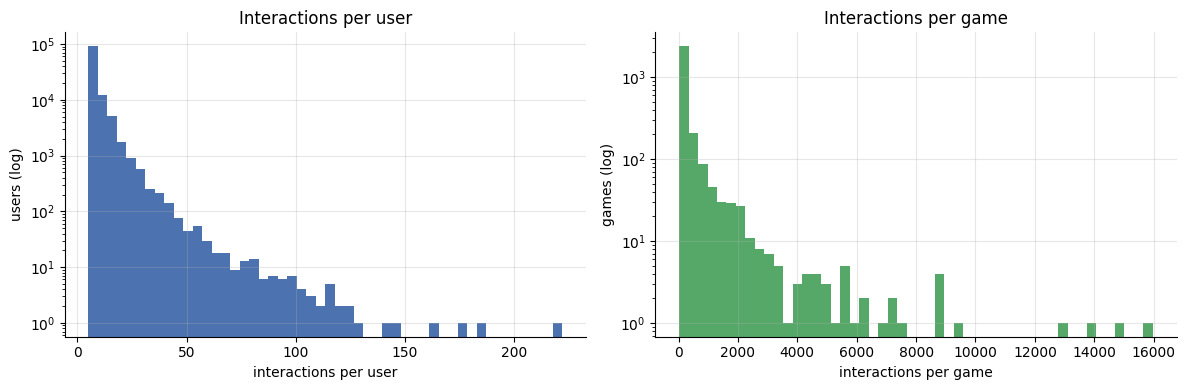

avg per user: 7.94 | avg per game: 313.77


In [3]:
# Distribution of interactions per user and per game
# Распределение взаимодействий на юзера и на игру
upc = inter["user_id"].value_counts()
gpc = inter["game_id"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(upc, bins=50, color="#4C72B0")
axes[0].set_yscale("log")
axes[0].set_xlabel("interactions per user")
axes[0].set_ylabel("users (log)")
axes[0].set_title("Interactions per user")

axes[1].hist(gpc, bins=50, color="#55A868")
axes[1].set_yscale("log")
axes[1].set_xlabel("interactions per game")
axes[1].set_ylabel("games (log)")
axes[1].set_title("Interactions per game")
plt.tight_layout()
plt.show()

print("avg per user:", round(n_inter / n_users, 2),
      "| avg per game:", round(n_inter / n_games, 2))

## Leave-Last-Out Split

For each user we hold out the most recent interaction as test and keep everything earlier as train.
This is a temporal split: the last action is part of the user history, regardless of its label.

```
User A

●────●────●────★
               │
               └── Test

Train: ● earlier interactions    Test: ★ last interaction
```

## Split leave-last-out

Для каждого пользователя последнее по времени взаимодействие уходит в test, всё более раннее — в train.
Это временной split: последнее действие — часть истории пользователя, независимо от его label.

In [4]:
# Build the leave-last-out split and save train / test
# Строим leave-last-out split и сохраняем train / test
train, test = leave_last_out(inter)

train.to_parquet(DATA / "processed" / "train.parquet", index=False)
test.to_parquet(DATA / "processed" / "test.parquet", index=False)
print("train:", f"{len(train):,}", "| test:", f"{len(test):,}")

train: 787,585 | test: 113,552


## Split Validation

A few cheap but important checks that the split is correct and reproducible.

## Проверка разбиения

Несколько дешёвых, но важных проверок, что split корректен и воспроизводим.

In [5]:
# Every test user must also appear in train
# Каждый test-юзер должен быть и в train
assert set(test["user_id"]).issubset(set(train["user_id"]))

# Train and test rows must not overlap
# Строки train и test не пересекаются
assert len(set(train.index) & set(test.index)) == 0

# Train happens no later than test (temporal order)
# Train не позже test (временной порядок)
assert train["unix_timestamp_created"].max() <= test["unix_timestamp_created"].max()

# Same set of users in train and test
# Одинаковый набор юзеров в train и test
assert train["user_id"].nunique() == test["user_id"].nunique()

# Exactly one test interaction per user (definition of leave-last-out)
# Ровно одно test-взаимодействие на юзера (определение leave-last-out)
assert (test.groupby("user_id").size() == 1).all()

print("split validation passed")

split validation passed


## Dataset Validation Summary

Final summary of the validated dataset and the saved split. Split parameters are also stored in `split_metadata.json` for reproducibility.

## Итог проверки датасета

Итоговая сводка по проверенному датасету и сохранённому split. Параметры split также сохраняются в `split_metadata.json` для воспроизводимости.

In [6]:
# Summary table
# Сводная таблица
sparsity = 1 - n_inter / (n_users * n_games)
summary = pd.DataFrame({
    "Metric": ["Users", "Games", "Interactions", "Sparsity",
               "Avg interactions / user", "Avg interactions / game",
               "Train size", "Test size"],
    "Value": [f"{n_users:,}", f"{n_games:,}", f"{n_inter:,}", f"{sparsity:.4%}",
              round(n_inter / n_users, 2), round(n_inter / n_games, 2),
              f"{len(train):,}", f"{len(test):,}"],
})
print(summary.to_string(index=False))

# Save split metadata for reproducibility
# Сохраняем метаданные split для воспроизводимости
metadata = {
    "dataset": "interactions.parquet",
    "strategy": "leave_last_out",
    "timestamp_column": "unix_timestamp_created",
    "tie_break": "game_id",
    "n_users": int(n_users),
    "n_games": int(n_games),
    "train_size": int(len(train)),
    "test_size": int(len(test)),
}
with open(DATA / "processed" / "split_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("\nsaved split_metadata.json")

                 Metric    Value
                  Users  113,552
                  Games    2,872
           Interactions  901,137
               Sparsity 99.7237%
Avg interactions / user     7.94
Avg interactions / game   313.77
             Train size  787,585
              Test size  113,552

saved split_metadata.json


**Conclusion**

The dataset satisfies all predefined quality criteria and is ready for recommendation model training.

**Вывод**

Датасет удовлетворяет всем заданным критериям качества и готов к обучению рекомендательных моделей.

## Next Step

The leave-last-out split defined in this notebook is the project's **Evaluation Protocol**: it will be used consistently across all subsequent recommendation models (ALS, Two-Tower, Ranker) to ensure a fair comparison.

Note: `unix_timestamp_created` is kept in train/test only for the split. Models will define an explicit `FEATURE_COLUMNS` list so that the timestamp never leaks into training.

The next notebook builds the first baselines and the evaluation harness.

## Следующий этап

Split leave-last-out, определённый в этом ноутбуке, — это **Evaluation Protocol** проекта: он будет использоваться одинаково для всех последующих моделей (ALS, Two-Tower, Ranker), чтобы сравнение было честным.

Важно: `unix_timestamp_created` остаётся в train/test только для split. Модели будут явно задавать список `FEATURE_COLUMNS`, чтобы timestamp не попал в обучение.

Следующий ноутбук строит первые baselines и eval harness.